In [ ]:
print("Cleanning up workspace ...")
!rm -rf *
print("Installing graphviz ...")
!sudo apt-get install graphviz 1>/dev/null
print("Downloading MCUNet codebase ...")
!wget https://www.dropbox.com/s/3y2n2u3mfxczwcb/mcunetv2-dev-main.zip?dl=0 >/dev/null
!unzip mcunetv2-dev-main.zip* 1>/dev/null
!mv mcunetv2-dev-main/* . 1>/dev/null
print("Downloading VWW dataset ...")
!wget https://www.dropbox.com/s/169okcuuv64d4nn/data.zip?dl=0 >/dev/null
print("Unzipping VWW dataset ...")
!unzip data.zip* 1>/dev/null
print("Installing thop and onnx ...")
!pip install thop 1>/dev/null
!pip install onnx 1>/dev/null

In [3]:
import argparse
import json
from PIL import Image
from tqdm import tqdm
import copy
import math
import numpy as np
import os
import random
import torch
from torch import nn
from collections import OrderedDict, defaultdict
from typing import Union, List
from torchvision import datasets, transforms
from mcunet.tinynas.search.accuracy_predictor import (
    AccuracyDataset,
    MCUNetArchEncoder,
)

from mcunet.tinynas.elastic_nn.networks.ofa_mcunets import OFAMCUNets
from mcunet.utils.mcunet_eval_helper import calib_bn, validate
from mcunet.utils.arch_visualization_helper import draw_arch


%matplotlib inline
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
def build_val_data_loader(data_dir, resolution, batch_size=128, split=0):
    # split = 0: real val set, split = 1: holdout validation set
    assert split in [0, 1]
    normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    kwargs = {"num_workers": min(8, os.cpu_count()), "pin_memory": False}

    val_transform = transforms.Compose([
            transforms.Resize(
                (resolution, resolution)
            ),  # if center crop, the person might be excluded
            transforms.ToTensor(),
            normalize,
        ]
    )
    val_dataset = datasets.ImageFolder(data_dir, transform=val_transform)
    val_dataset = torch.utils.data.Subset(
        val_dataset, list(range(len(val_dataset)))[split::2])

    val_loader = torch.utils.data.DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False, **kwargs
    )
    return val_loader

In [5]:
import glob, random
org_data_dir = "data/vww-s256/val"

all_pos_dir = glob.glob(org_data_dir+"/1/*")
all_neg_dir = glob.glob(org_data_dir+"/0/*")
random.shuffle(all_pos_dir)
random.shuffle(all_neg_dir)

train_data_dir = "data/vww-s256/train"
val_data_dir = "data/vww-s256/val"
test_data_dir = "data/vww-s256/test"

for data_dir, percent in zip([train_data_dir, test_data_dir], [0.4, 0.5]):
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
        os.makedirs(data_dir + "/1")
        os.makedirs(data_dir+ "/0")
        for image_name in all_pos_dir[:int(len(all_pos_dir)*percent)]:
            os.rename(image_name, data_dir + "/1/" + image_name.split("/")[-1])
            all_pos_dir.remove(image_name)
        for image_name in all_neg_dir[:int(len(all_neg_dir)*percent)]:
            os.rename(image_name, data_dir + "/0/" + image_name.split("/")[-1])
            all_neg_dir.remove(image_name)

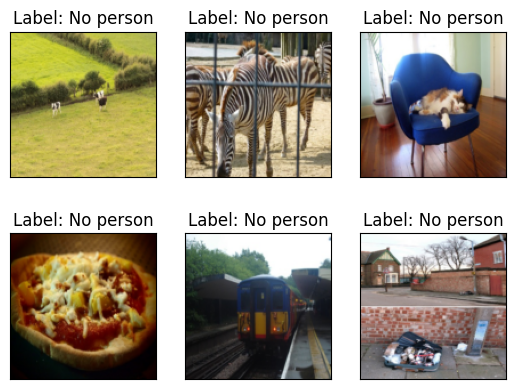

In [6]:
val_data_loader = build_val_data_loader(val_data_dir, resolution=128, batch_size=1)

vis_x, vis_y = 2, 3
fig, axs = plt.subplots(vis_x, vis_y)

num_images = 0
for data, label in val_data_loader:
    img = np.array((((data + 1) / 2) * 255).numpy(), dtype=np.uint8)
    img = img[0].transpose(1, 2, 0)
    if label.item() == 0:
        label_text = "No person"
    else:
        label_text = "Person"
    axs[num_images // vis_y][num_images % vis_y].imshow(img)
    axs[num_images // vis_y][num_images % vis_y].set_title(f"Label: {label_text}")
    axs[num_images // vis_y][num_images % vis_y].set_xticks([])
    axs[num_images // vis_y][num_images % vis_y].set_yticks([])
    num_images += 1
    if num_images > vis_x * vis_y - 1:
        break

plt.show()

In [7]:
device = "cuda:0"
ofa_network = OFAMCUNets(
    n_classes=2,
    bn_param=(0.1, 1e-3),
    dropout_rate=0.0,
    base_stage_width="mcunet384",
    width_mult_list=[0.5, 0.75, 1.0],
    ks_list=[3, 5, 7],
    expand_ratio_list=[3, 4, 6],
    depth_list=[0, 1, 2],
    base_depth=[1, 2, 2, 2, 2],
    fuse_blk1=True,
    se_stages=[False, [False, True, True, True], True, True, True, False],
)

ofa_network.load_state_dict(
    torch.load("vww_supernet.pth", map_location="cpu")["state_dict"], strict=True
)

ofa_network = ofa_network.to(device)

# Search the best sub-network of trained model

In [8]:
from mcunet.utils.pytorch_utils import count_peak_activation_size, count_net_flops, count_parameters

def evaluate_sub_network(ofa_network, cfg, image_size=None):
    if "image_size" in cfg:
        image_size = cfg["image_size"]
    batch_size = 128
    # step 1. sample the active subnet with the given config.
    ofa_network.set_active_subnet(**cfg)
    # step 2. extract the subnet with corresponding weights.
    subnet = ofa_network.get_active_subnet().to(device)
    # step 3. calculate the efficiency stats of the subnet.
    peak_memory = count_peak_activation_size(subnet, (1, 3, image_size, image_size))
    macs = count_net_flops(subnet, (1, 3, image_size, image_size))
    params = count_parameters(subnet)
    # step 4. perform BN parameter re-calibration.
    calib_bn(subnet, test_data_dir, batch_size, image_size)
    # step 5. define the validation dataloader.
    val_loader = build_val_data_loader(test_data_dir, image_size, batch_size)
    # step 6. validate the accuracy.
    acc = validate(subnet, val_loader)
    return acc, peak_memory, macs, params

In [9]:
def visualize_subnet(cfg):
    draw_arch(cfg["ks"], cfg["e"], cfg["d"], cfg["image_size"], out_name="viz/subnet")
    im = Image.open("viz/subnet.png")
    im = im.rotate(90, expand=1)
    fig = plt.figure(figsize=(im.size[0] / 250, im.size[1] / 250))
    plt.axis("off")
    plt.imshow(im)
    plt.show()

Validate: 100%|██████████| 10/10 [00:04<00:00,  2.18it/s, loss=0.207, top1=92.5]


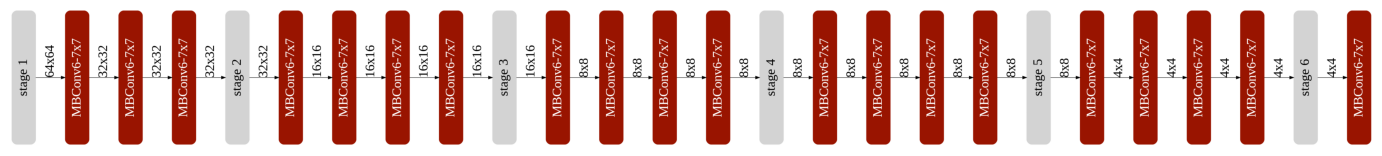

The accuracy of the sampled subnet: #params= 2.5M, accuracy= 92.5%.
The effiency of the sampled subnet: #peak_mems= 0.5MB, macs= 140.9M.


In [10]:
cfg = ofa_network.sample_active_subnet(sample_function=max, image_size=128)
acc, peak_mems, macs, params = evaluate_sub_network(ofa_network, cfg)
visualize_subnet(cfg)
print(f"The accuracy of the sampled subnet: #params={params/1e6: .1f}M, accuracy={acc: .1f}%.")
print(f"The effiency of the sampled subnet: #peak_mems={peak_mems/1e6: .1f}MB, macs={macs/1e6: .1f}M.")

## Train Accuracy prediction model

In [11]:
class AnalyticalEfficiencyPredictor:
    def __init__(self, net):
        self.net = net

    def get_efficiency(self, spec: dict):
        self.net.set_active_subnet(**spec)
        subnet = self.net.get_active_subnet()
        if torch.cuda.is_available():
            subnet = subnet.cuda()
        data_shape = (1, 3, image_size, image_size)
        macs =count_net_flops(subnet, (1, 3, image_size, image_size))
        peak_memory = count_peak_activation_size(subnet, (1, 3, image_size, image_size))

        return dict(millionMACs=macs / 1e6, KBPeakMemory=peak_memory / 1024)

    def satisfy_constraint(self, measured: dict, target: dict):
        for key in measured:
            # if the constraint is not specified, we just continue
            if key not in target:
                continue
            # if we exceed the constraint, just return false.
            if measured[key] > target[key]:
                return False
        # no constraint violated, return true.
        return True

In [12]:
image_size_list = [96, 112, 128, 144, 160]
arch_encoder = MCUNetArchEncoder(
    image_size_list=image_size_list,
    base_depth=ofa_network.base_depth,
    depth_list=ofa_network.depth_list,
    expand_list=ofa_network.expand_ratio_list,
    width_mult_list=ofa_network.width_mult_list,
)

In [13]:
class AccuracyPredictor(nn.Module):
    def __init__(
        self,
        arch_encoder,
        hidden_size=400,
        n_layers=3,
        checkpoint_path=None,
        device="cuda:0",
    ):
        super(AccuracyPredictor, self).__init__()
        self.arch_encoder = arch_encoder
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        self.device = device

        layers = []
        layers.append(nn.Linear(self.arch_encoder.n_dim, hidden_size, bias=True))
        layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_size, hidden_size, bias=True))
        layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_size, hidden_size, bias=True))
        layers.append(nn.ReLU())

        layers.append(nn.Linear(self.hidden_size, 1, bias=False))
        self.layers = nn.Sequential(*layers)
        self.base_acc = nn.Parameter(
            torch.zeros(1, device=self.device), requires_grad=False
        )

        if checkpoint_path is not None and os.path.exists(checkpoint_path):
            checkpoint = torch.load(checkpoint_path, map_location="cpu")
            if "state_dict" in checkpoint:
                checkpoint = checkpoint["state_dict"]
            self.load_state_dict(checkpoint)
            print("Loaded checkpoint from %s" % checkpoint_path)

        self.layers = self.layers.to(self.device)

    def forward(self, x):
        y = self.layers(x).squeeze()
        return y + self.base_acc

    def predict_acc(self, arch_dict_list):
        X = [self.arch_encoder.arch2feature(arch_dict) for arch_dict in arch_dict_list]
        X = torch.tensor(np.array(X)).float().to(self.device)
        return self.forward(X)

In [14]:
os.makedirs("pretrained", exist_ok=True)
acc_pred_checkpoint_path = (
    f"pretrained/{ofa_network.__class__.__name__}_acc_predictor.pth"
)
acc_predictor = AccuracyPredictor(
    arch_encoder,
    hidden_size=400,
    n_layers=1,
    checkpoint_path=None,
    device=device,
)
print(acc_predictor)

AccuracyPredictor(
  (layers): Sequential(
    (0): Linear(in_features=128, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=400, bias=True)
    (3): ReLU()
    (4): Linear(in_features=400, out_features=400, bias=True)
    (5): ReLU()
    (6): Linear(in_features=400, out_features=1, bias=False)
  )
)


In [15]:
acc_dataset = AccuracyDataset("acc_datasets")
train_loader, valid_loader, base_acc = acc_dataset.build_acc_data_loader(
    arch_encoder=arch_encoder
)

Loading data: 100%|██████████| 50000/50000 [00:02<00:00, 24764.80it/s]


Train Size: 40000, Valid Size: 10000


In [24]:
criterion = torch.nn.L1Loss().to(device)
optimizer = torch.optim.Adam(acc_predictor.parameters())
# the default value is zero
acc_predictor.base_acc.data += base_acc
for epoch in tqdm(range(10)):
    acc_predictor.train()
    for (data, label) in tqdm(train_loader, desc="Epoch%d" % (epoch + 1), position=0, leave=True):
        # step 1. Move the data and labels to device (cuda:0).
        data = data.to(device)
        label = label.to(device)
        pred = acc_predictor(data)
        loss = criterion(label, pred)

    acc_predictor.eval()
    with torch.no_grad():
        with tqdm(total=len(valid_loader), desc="Val", position=0, leave=True) as t:
            for (data, label) in valid_loader:
                data = data.to(device)
                label = label.to(device)
                pred = acc_predictor(data)
                loss = criterion(label, pred)
                t.set_postfix({"loss": loss.item()})
                t.update(1)

if not os.path.exists(acc_pred_checkpoint_path):
    torch.save(acc_predictor.cpu().state_dict(), acc_pred_checkpoint_path)

100%|██████████| 10/10 [00:25<00:00,  2.59s/it]


Val:   0%|          | 0/40 [00:00<?, ?it/s]


Text(0.5, 1.0, 'Correlation between predicted accuracy and real accuracy')

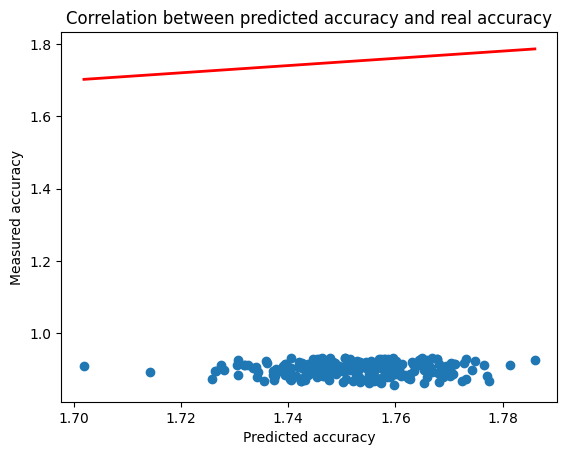

In [25]:
predicted_accuracies = []
ground_truth_accuracies = []
acc_predictor = acc_predictor.to("cuda:0")
acc_predictor.eval()
with torch.no_grad():
    with tqdm(total=len(valid_loader), desc="Val") as t:
        for (data, label) in valid_loader:
            data = data.to(device)
            label = label.to(device)
            pred = acc_predictor(data)
            predicted_accuracies += pred.cpu().numpy().tolist()
            ground_truth_accuracies += label.cpu().numpy().tolist()
            if len(predicted_accuracies) > 200:
                break
plt.scatter(predicted_accuracies, ground_truth_accuracies)
# draw y = x
min_acc, max_acc = min(predicted_accuracies), max(predicted_accuracies)
plt.plot([min_acc, max_acc], [min_acc, max_acc], c="red", linewidth=2)
plt.xlabel("Predicted accuracy")
plt.ylabel("Measured accuracy")
plt.title("Correlation between predicted accuracy and real accuracy")

## Neural Architecture Search via Accuracy prediction model

In [26]:
class EvolutionSearcher:
    def __init__(self, efficiency_predictor, accuracy_predictor, **kwargs):
        self.efficiency_predictor = efficiency_predictor
        self.accuracy_predictor = accuracy_predictor

        # evolution hyper-parameters
        self.arch_mutate_prob = kwargs.get("arch_mutate_prob", 0.1)
        self.resolution_mutate_prob = kwargs.get("resolution_mutate_prob", 0.5)
        self.population_size = kwargs.get("population_size", 100)
        self.max_time_budget = kwargs.get("max_time_budget", 500)
        self.parent_ratio = kwargs.get("parent_ratio", 0.25)
        self.mutation_ratio = kwargs.get("mutation_ratio", 0.5)

    def update_hyper_params(self, new_param_dict):
        self.__dict__.update(new_param_dict)

    def random_valid_sample(self, constraint):
        # randomly sample subnets until finding one that satisfies the effiency constraint
        while True:
            sample = self.accuracy_predictor.arch_encoder.random_sample_arch()
            efficiency = self.efficiency_predictor.get_efficiency(sample)
            if self.efficiency_predictor.satisfy_constraint(efficiency, constraint):
                return sample, efficiency

    def mutate_sample(self, sample, constraint):
        while True:
            new_sample = copy.deepcopy(sample)

            self.accuracy_predictor.arch_encoder.mutate_resolution(new_sample, self.resolution_mutate_prob)
            self.accuracy_predictor.arch_encoder.mutate_width(new_sample, self.arch_mutate_prob)
            self.accuracy_predictor.arch_encoder.mutate_arch(new_sample, self.arch_mutate_prob)

            efficiency = self.efficiency_predictor.get_efficiency(new_sample)
            if self.efficiency_predictor.satisfy_constraint(efficiency, constraint):
                return new_sample, efficiency

    def crossover_sample(self, sample1, sample2, constraint):
        while True:
            new_sample = copy.deepcopy(sample1)
            for key in new_sample.keys():
                if not isinstance(new_sample[key], list):
                    new_sample[key] = random.choice([sample1[key], sample2[key]])
                else:
                    for i in range(len(new_sample[key])):
                        new_sample[key][i] = random.choice([sample1[key][i], sample2[key][i]])
            efficiency = self.efficiency_predictor.get_efficiency(new_sample)
            if self.efficiency_predictor.satisfy_constraint(efficiency, constraint):
                return new_sample, efficiency

    def run_search(self, constraint, **kwargs):
        self.update_hyper_params(kwargs)

        mutation_numbers = int(round(self.mutation_ratio * self.population_size))
        parents_size = int(round(self.parent_ratio * self.population_size))

        best_valids = [-100]
        population = []  # (acc, sample) tuples
        child_pool = []
        best_info = None
        # generate random population
        for _ in range(self.population_size):
            sample, efficiency = self.random_valid_sample(constraint)
            child_pool.append(sample)

        accs = self.accuracy_predictor.predict_acc(child_pool)
        for i in range(self.population_size):
            population.append((accs[i].item(), child_pool[i]))

        # evolving the population
        with tqdm(total=self.max_time_budget) as t:
            for i in range(self.max_time_budget):
                population = sorted(population, key=lambda x: x[0], reverse=True)
                population = population[:parents_size]

                # update best info
                acc = population[0][0]
                if acc > best_valids[-1]:
                    best_valids.append(acc)
                    best_info = population[0]
                else:
                    best_valids.append(best_valids[-1])

                child_pool = []
                for j in range(mutation_numbers):
                    # randomly choose a sample
                    par_sample = population[np.random.randint(parents_size)][1]
                    # mutate this sample
                    new_sample, efficiency = self.mutate_sample(par_sample, constraint)
                    child_pool.append(new_sample)

                for j in range(self.population_size - mutation_numbers):
                    # randomly choose two samples
                    par_sample1 = population[np.random.randint(parents_size)][1]
                    par_sample2 = population[np.random.randint(parents_size)][1]
                    # crossover
                    new_sample, efficiency = self.crossover_sample(
                        par_sample1, par_sample2, constraint
                    )
                    child_pool.append(new_sample)
                # predict accuracy with the accuracy predictor
                accs = self.accuracy_predictor.predict_acc(child_pool)
                for j in range(self.population_size):
                    population.append((accs[j].item(), child_pool[j]))

                t.update(1)

        return best_info

In [34]:
def search_and_measure_acc(agent, constraint, **kwargs):
    best_info = agent.run_search(constraint)
    print(best_info[1])
    # get searched subnet
    ofa_network.set_active_subnet(**best_info[1])
    subnet = ofa_network.get_active_subnet().to(device)
    # calibrate bn
    calib_bn(subnet, val_data_dir, 128, best_info[1]["image_size"])
    # build val loader
    val_loader = build_val_data_loader(val_data_dir, best_info[1]["image_size"], 128)
    # measure accuracy
    acc = validate(subnet, val_loader)
    # print best_info
    print(f"Accuracy of the selected subnet: {acc}")
    # visualize model architecture
    visualize_subnet(best_info[1])
    return acc, subnet

Evolutionary search with constraint: MACs <= 50M


100%|██████████| 10/10 [00:25<00:00,  2.54s/it]

{'ks': [7, 5, 7, 7, 3, 3, 5, 5, 5, 7, 5, 5, 5, 7, 5, 3, 7, 7, 5, 7], 'e': [4, 4, 4, 4, 4, 4, 6, 3, 6, 6, 6, 4, 4, 3, 4, 6, 4, 3, 6, 4], 'd': [1, 0, 1, 2, 1, 1], 'image_size': 144, 'wid': 0}



Validate: 100%|██████████| 10/10 [00:02<00:00,  3.35it/s, loss=0.243, top1=90.7]


Accuracy of the selected subnet: 90.65343263940046


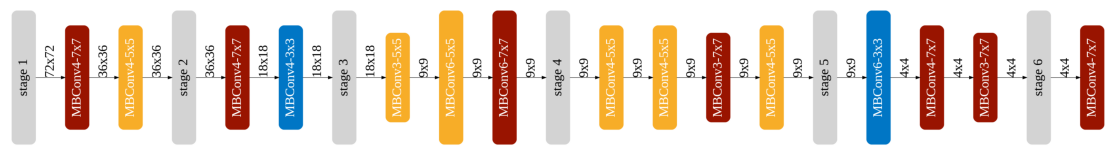

Evolutionary search with constraint: MACs <= 100M


100%|██████████| 10/10 [00:25<00:00,  2.54s/it]

{'ks': [7, 7, 5, 5, 7, 3, 7, 3, 7, 7, 7, 7, 3, 5, 3, 5, 7, 3, 7, 5], 'e': [6, 4, 6, 6, 6, 4, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 6, 3, 3, 6], 'd': [0, 2, 1, 1, 1, 2], 'image_size': 160, 'wid': 1}



Validate: 100%|██████████| 10/10 [00:03<00:00,  3.13it/s, loss=0.213, top1=92.1]


Accuracy of the selected subnet: 92.14226634212523


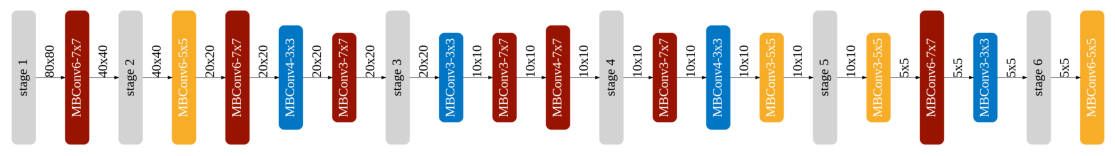

Evolutionary search with constraint: Peak memory <= 256KB


100%|██████████| 10/10 [00:27<00:00,  2.71s/it]

{'ks': [7, 7, 7, 7, 3, 5, 5, 5, 7, 3, 5, 5, 5, 7, 3, 5, 3, 7, 5, 3], 'e': [3, 3, 3, 3, 3, 4, 3, 6, 4, 4, 4, 4, 4, 3, 4, 4, 4, 6, 6, 3], 'd': [0, 0, 2, 1, 2, 2], 'image_size': 128, 'wid': 1}



Validate: 100%|██████████| 10/10 [00:03<00:00,  2.62it/s, loss=0.256, top1=90]


Accuracy of the selected subnet: 89.99172866354311


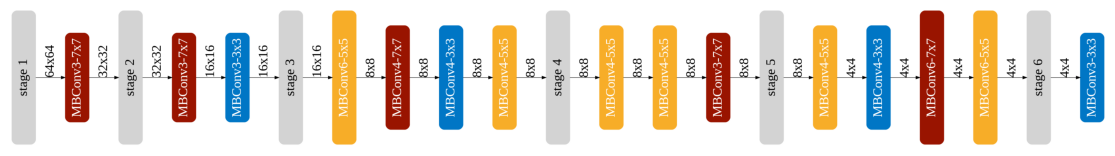

Evolutionary search with constraint: Peak memory <= 512KB


100%|██████████| 10/10 [00:28<00:00,  2.86s/it]

{'ks': [5, 3, 7, 7, 5, 3, 3, 5, 7, 7, 7, 3, 7, 5, 5, 7, 5, 7, 5, 3], 'e': [4, 4, 4, 6, 6, 6, 4, 6, 6, 4, 3, 4, 6, 3, 6, 6, 6, 4, 4, 4], 'd': [1, 1, 2, 1, 1, 0], 'image_size': 112, 'wid': 1}



Validate: 100%|██████████| 10/10 [00:03<00:00,  3.24it/s, loss=0.275, top1=89.6]


Accuracy of the selected subnet: 89.57816373384915


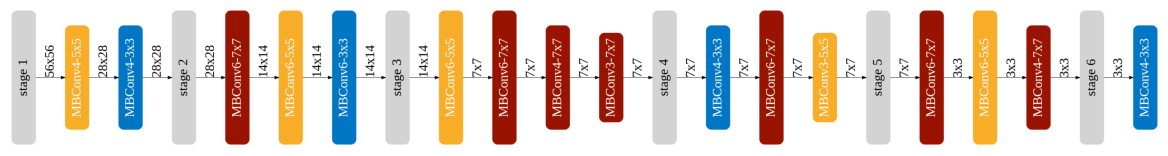

In [35]:
image_size = 128
random.seed(1)
np.random.seed(1)

evo_params = {
    'arch_mutate_prob': 0.1, # The probability of architecture mutation in evolutionary search
    'resolution_mutate_prob': 0.1, # The probability of resolution mutation in evolutionary search
    'population_size': 10,  # The size of the population
    'max_time_budget': 10,
    'parent_ratio': 0.1,
    'mutation_ratio': 0.1,
}

efficiency_predictor = AnalyticalEfficiencyPredictor(ofa_network)

nas_agent = EvolutionSearcher(efficiency_predictor, acc_predictor, **evo_params)
# MACs-constrained search
subnets_evo_macs = {}
for millonMACs in [50, 100]:
    search_constraint = dict(millionMACs=millonMACs)
    print(f"Evolutionary search with constraint: MACs <= {millonMACs}M")
    subnets_evo_macs[millonMACs] = search_and_measure_acc(nas_agent, search_constraint)

# memory-constrained search
subnets_evo_memory = {}
for KBPeakMemory in [256, 512]:
    search_constraint = dict(KBPeakMemory=KBPeakMemory)
    print(f"Evolutionary search with constraint: Peak memory <= {KBPeakMemory}KB")
    subnets_evo_memory[KBPeakMemory] = search_and_measure_acc(nas_agent, search_constraint)


In [39]:
dense_model_accuracy, chosen_model = subnets_evo_memory[256]
test_loader = build_val_data_loader("data/vww-s256/test",160, 128)
test_acc = validate(chosen_model, test_loader)
print("\nTest accuracy of the searched model  = ", test_acc, "%")

Validate: 100%|██████████| 10/10 [00:07<00:00,  1.38it/s, loss=0.194, top1=92.6]


Test accuracy of the searched model  =  92.63854430193147 %
